# Least Squares Applications

Notebook ini merangkum Chapter 12 dari *Practical Linear Algebra for Data Science*. Chapter ini membahas penerapan **least squares** pada data nyata dan beberapa konsep lanjutan yang sering muncul dalam statistik serta machine learning, seperti **multicollinearity**, **regularization**, **polynomial regression**, dan **grid search**.

Pembahasan dibuat mengikuti format Chapter 11: ada tujuan pembelajaran, ringkasan chapter, struktur pembahasan, penjelasan teori per bagian, rumus matematis yang relevan, kode inti, ringkasan konsep, dan kesimpulan.

## Tujuan Pembelajaran

- Memahami penerapan least squares pada data nyata.
- Menjelaskan pentingnya inspeksi visual sebelum melakukan modeling.
- Membuat design matrix untuk regresi sederhana.
- Menghitung koefisien regresi menggunakan least squares.
- Mengevaluasi model menggunakan $R^2$.
- Memahami regression table menggunakan `statsmodels`.
- Menjelaskan multicollinearity sebagai linear dependence pada design matrix.
- Memahami regularization sebagai shifting untuk meningkatkan stabilitas numerik.
- Membuat polynomial regression untuk curve fitting.
- Memahami grid search sebagai alternatif pencarian parameter model.

## Ringkasan Chapter

Chapter ini menunjukkan bagaimana least squares digunakan dalam aplikasi data nyata. Contoh pertama menggunakan dataset penyewaan sepeda di Seoul untuk memprediksi jumlah sepeda yang disewa berdasarkan rainfall dan season. Walaupun model dapat dihitung tanpa error, hasilnya menunjukkan bahwa model linear sederhana belum tentu sesuai untuk semua data.

Chapter ini menekankan pentingnya inspeksi visual terhadap data. Scatterplot dan correlation matrix dapat membantu memahami hubungan antar variabel sebelum memilih model statistik. Pada contoh bike rental, hubungan antara rainfall, season, dan rented bike count terlihat tidak sepenuhnya linear, sehingga least squares linear menghasilkan fit yang kurang baik dan bahkan memprediksi jumlah sepeda negatif.

Bagian berikutnya memperkenalkan regression table menggunakan `statsmodels`. Regression table memberikan informasi seperti coefficients, $R^2$, standard error, t-statistic, dan p-value. Namun, chapter tetap menekankan bahwa pemahaman linear algebra diperlukan agar hasil statistik tidak diterima begitu saja.

Chapter juga membahas multicollinearity, yaitu kondisi ketika salah satu predictor dapat diprediksi secara linear dari predictor lain. Dalam linear algebra, ini sama dengan linear dependence, reduced-rank design matrix, atau singular matrix. Kondisi ini membuat least squares menjadi tidak stabil jika diselesaikan dengan inverse biasa.

Regularization diperkenalkan sebagai cara untuk meningkatkan stabilitas numerik dengan melakukan shifting pada matrix. Chapter kemudian membahas polynomial regression, yaitu regresi dengan design matrix berisi $x^0, x^1, \ldots, x^n$, serta grid search sebagai metode empiris untuk mencari parameter model ketika solusi linear least squares tidak dapat digunakan.

## Struktur Pembahasan Chapter

| Bagian | Inti Pembahasan |
|---|---|
| Predicting Bike Rentals | Least squares digunakan untuk memprediksi bike rental count dari rainfall dan season. |
| Regression Table | `statsmodels` digunakan untuk menghasilkan tabel regresi. |
| Multicollinearity | Linear dependence pada design matrix dapat membuat solusi least squares tidak stabil. |
| Regularization | Matrix di-shift untuk meningkatkan stabilitas numerik dan mengurangi sensitivitas model. |
| Polynomial Regression | Design matrix dibuat dari pangkat-pangkat $x$ untuk curve fitting. |
| Grid Search | Parameter model dicari dengan mencoba banyak kombinasi nilai pada grid. |

## Persiapan Library

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

try:
    import statsmodels.api as sm
    STATSMODELS_AVAILABLE = True
except Exception:
    STATSMODELS_AVAILABLE = False

np.random.seed(2024)

## Predicting Bike Rentals Based on Weather

Chapter ini menggunakan dataset bike rental di Seoul. Tujuannya adalah memprediksi jumlah sepeda yang disewa berdasarkan beberapa variabel cuaca dan season. Variabel dependent-nya adalah **Rented Bike Count**, sedangkan contoh predictor yang digunakan adalah **Rainfall(mm)** dan **Seasons**.

Sebelum membuat model, chapter menekankan bahwa data perlu diinspeksi secara visual. Pada data asli, rainfall merupakan variabel yang sparse karena sebagian besar nilainya nol. Hubungan antara bike rental count dan rainfall juga tidak tampak sebagai garis linear sederhana.

## Design Matrix untuk Bike Rental

Pada model pertama, design matrix berisi tiga columns:

1. Rainfall
2. Season yang sudah dibinarisasi
3. Intercept

Season dibinarisasi karena season adalah categorical variable. Autumn/winter diberi label 0, sedangkan spring/summer diberi label 1.

Secara umum modelnya dapat ditulis sebagai:

$$
y = \beta_0(\text{rainfall}) + \beta_1(\text{season}) + \beta_2(1)
$$

atau dalam bentuk matrix:

$$
X\beta = y
$$

Keterangan:

- $X$ = design matrix
- $\beta$ = coefficient vector
- $y$ = rented bike count

In [2]:
# Simulasi data sederhana yang mengikuti ide chapter:
# rainfall sparse, season binary, dan bike count sebagai dependent variable

n = 1000

rainfall = np.random.exponential(scale=1.2, size=n)
rainfall[np.random.rand(n) < 0.75] = 0  # membuat rainfall sparse

season = np.zeros(n)
season[250:750] = 1  # 0 = autumn/winter, 1 = spring/summer

bike_count = 530 - 80*rainfall + 369*season + np.random.normal(0, 500, n)
bike_count = np.maximum(bike_count, 0)

desmat = np.column_stack((rainfall, season, np.ones(n)))
y = bike_count.reshape(-1, 1)

beta = np.linalg.lstsq(desmat, y, rcond=None)[0]

print("Beta coefficients:")
print(np.round(beta, 3))

Beta coefficients:
[[-73.921]
 [273.251]
 [616.501]]


## Interpretasi Koefisien Model

Pada chapter, beta untuk rainfall bernilai negatif, sedangkan beta untuk season bernilai positif. Interpretasinya:

- Rainfall negatif berarti semakin tinggi rainfall, jumlah penyewaan sepeda cenderung turun.
- Season positif berarti spring/summer memiliki lebih banyak bike rentals dibanding autumn/winter.
- Intercept menunjukkan baseline prediction saat rainfall 0 dan season 0.

Namun, hasil model tetap perlu dicek secara visual dan kuantitatif karena coefficient yang masuk akal tidak selalu berarti model memiliki fit yang baik.

## Evaluasi Model dengan $R^2$

Chapter mengevaluasi model menggunakan $R^2$. Jika model sempurna, predicted values akan berada pada diagonal terhadap observed values.

### Rumus $R^2$

$$
R^2 = 1 - \frac{SSE}{SST}
$$

Keterangan:

- $SSE = \sum (y-\hat{y})^2$
- $SST = \sum (y-\bar{y})^2$
- $y$ = observed data
- $\hat{y}$ = predicted data
- $\bar{y}$ = rata-rata observed data

Nilai $R^2$ yang kecil menunjukkan bahwa model hanya menjelaskan sebagian kecil variance dalam data.

In [3]:
y_hat = desmat @ beta

sse = np.sum((y - y_hat)**2)
sst = np.sum((y - np.mean(y))**2)
r2 = 1 - sse/sst

print("R²:", round(float(r2), 3))

R²: 0.094


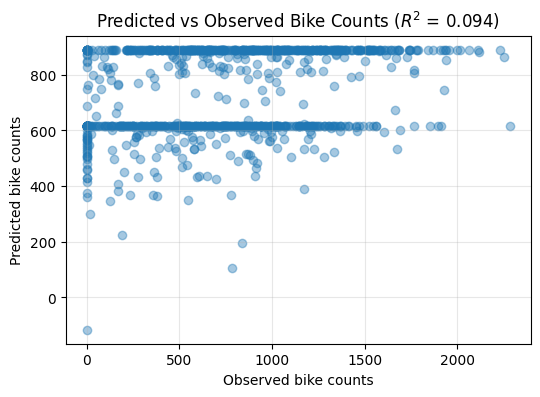

In [4]:
plt.figure(figsize=(6, 4))
plt.scatter(y, y_hat, alpha=0.4)
plt.xlabel("Observed bike counts")
plt.ylabel("Predicted bike counts")
plt.title(f"Predicted vs Observed Bike Counts ($R^2$ = {float(r2):.3f})")
plt.grid(alpha=0.3)
plt.show()

## Visual Inspection dan Keterbatasan Model Linear

Chapter menekankan bahwa model bisa saja benar secara matematis dan tidak menghasilkan error di Python, tetapi tetap tidak cocok secara statistik. Pada contoh bike rental, hubungan antar variabel terlihat nonlinear dan predicted bike count dapat menjadi negatif.

Ini menunjukkan bahwa data science bukan hanya memasukkan data ke rumus. Pemilihan model harus mempertimbangkan bentuk data, konteks variabel, dan interpretasi output.

## Regression Table Using `statsmodels`

Chapter memperkenalkan `statsmodels` untuk membuat regression table. Library ini umum digunakan dalam statistik karena dapat menampilkan informasi yang lebih lengkap dibanding hanya menghitung coefficient dengan NumPy.

Informasi penting dalam regression table:

| Komponen | Penjelasan |
|---|---|
| coef | Estimasi coefficient untuk setiap regressor. |
| R-squared | Proporsi variance yang dijelaskan model. |
| std err | Standard error dari coefficient. |
| t | Statistik uji untuk coefficient. |
| P>|t| | p-value untuk uji signifikansi coefficient. |

In [5]:
if STATSMODELS_AVAILABLE:
    Xsm = sm.add_constant(np.column_stack((rainfall, season)), has_constant="add")
    model = sm.OLS(bike_count, Xsm).fit()
    print(model.summary())
else:
    print("statsmodels tidak tersedia di environment ini.")

statsmodels tidak tersedia di environment ini.


## Multicollinearity

Multicollinearity terjadi ketika salah satu predictor variable dapat diprediksi secara linear dari predictor lain. Dalam bahasa linear algebra, multicollinearity sama dengan:

- linear dependence pada design matrix,
- reduced-rank design matrix,
- singular matrix.

Jika design matrix reduced-rank, maka matrix tersebut tidak memiliki left-inverse yang stabil. Akibatnya, solusi least squares menggunakan inverse biasa dapat menjadi tidak reliable.

## Contoh Multicollinearity

Misalkan terdapat predictor baru yang merupakan linear weighted combination dari rainfall dan season:

$$
x_3 = 2x_1 + 3x_2
$$

Maka column $x_3$ tidak memberikan informasi baru karena dapat dibentuk dari column lain.

Akibatnya, design matrix memiliki jumlah columns lebih banyak daripada rank-nya.

In [6]:
new_regressor = 2*rainfall + 3*season

X_multi = np.column_stack((rainfall, season, np.ones(n), new_regressor))

print("Design matrix size:", X_multi.shape)
print("Design matrix rank:", np.linalg.matrix_rank(X_multi))

Design matrix size: (1000, 4)
Design matrix rank: 3


In [7]:
corr = np.corrcoef(X_multi.T)

print("Correlation matrix:")
print(np.round(corr, 3))

Correlation matrix:
[[ 1.    -0.053    nan  0.729]
 [-0.053  1.       nan  0.645]
 [   nan    nan    nan    nan]
 [ 0.729  0.645    nan  1.   ]]


## Solving GLMs with Multicollinearity

Chapter menjelaskan bahwa GLM dengan reduced-rank design matrix masih bisa diselesaikan menggunakan metode tertentu, seperti modified QR procedure atau Moore-Penrose pseudoinverse. Solusi yang dipilih biasanya disebut **minimum norm solution**.

Namun, dalam analisis statistik biasa, multicollinearity sering menandakan masalah pada model, data entry, atau coding. Karena itu, reduced-rank design matrix sebaiknya diperiksa, bukan hanya langsung dipaksakan untuk fitting.

In [8]:
# Perbandingan solusi inverse biasa dan lstsq
try:
    beta_left_inverse = np.linalg.inv(X_multi.T @ X_multi) @ X_multi.T @ y
    pred_left_inverse = X_multi @ beta_left_inverse
    r2_left_inverse = 1 - np.sum((y - pred_left_inverse)**2) / np.sum((y - np.mean(y))**2)
except Exception as e:
    beta_left_inverse = None
    r2_left_inverse = None
    print("Left-inverse error:", e)

beta_lstsq = np.linalg.lstsq(X_multi, y, rcond=None)[0]
pred_lstsq = X_multi @ beta_lstsq
r2_lstsq = 1 - np.sum((y - pred_lstsq)**2) / np.sum((y - np.mean(y))**2)

print("R² from np.linalg.lstsq:", round(float(r2_lstsq), 4))
print("Beta from np.linalg.lstsq:")
print(np.round(beta_lstsq.T, 3))

R² from np.linalg.lstsq: 0.0939
Beta from np.linalg.lstsq:
[[-169.908  129.27   616.501   47.994]]


## Regularization

Regularization adalah istilah umum untuk berbagai cara memodifikasi model statistik. Tujuannya dapat berupa:

- meningkatkan stabilitas numerik,
- mengubah singular atau ill-conditioned matrix menjadi full-rank,
- mengurangi overfitting,
- membuat model lebih generalizable.

Chapter ini menghubungkan regularization dengan konsep **matrix shifting** dari chapter sebelumnya.

## Rumus Regularization

Chapter menggunakan regularization pada least squares sebagai berikut:

$$
\beta =
\left(
X^TX + \gamma \|X\|_F^2 I
\right)^{-1}
X^Ty
$$

Keterangan:

- $X$ = design matrix
- $y$ = observed data
- $\gamma$ = regularization parameter
- $\|X\|_F^2$ = squared Frobenius norm dari design matrix
- $I$ = identity matrix

Jika $\gamma = 0$, maka tidak ada regularization. Semakin besar $\gamma$, semakin kuat regularization yang diberikan.

In [9]:
def regularized_beta(X, y, gamma):
    return np.linalg.inv(
        X.T @ X + gamma * np.linalg.norm(X, "fro")**2 * np.eye(X.shape[1])
    ) @ X.T @ y

for gamma in [0, 0.01]:
    inv_part = np.linalg.inv(
        X_multi.T @ X_multi + gamma*np.linalg.norm(X_multi, "fro")**2*np.eye(X_multi.shape[1])
    )
    print(f"inv(X'X + {gamma}*I) size:", inv_part.shape)
    print(f"inv(X'X + {gamma}*I) rank:", np.linalg.matrix_rank(inv_part))
    print()

inv(X'X + 0*I) size: (4, 4)
inv(X'X + 0*I) rank: 1

inv(X'X + 0.01*I) size: (4, 4)
inv(X'X + 0.01*I) rank: 4



## Efek Regularization terhadap Fit Model

Regularization biasanya membuat model kurang sensitif terhadap data training. Pada full-rank design matrix, fit terhadap training data sering menurun ketika regularization meningkat. Namun, manfaat regularization biasanya dinilai pada test data atau validation data, bukan hanya pada training data.

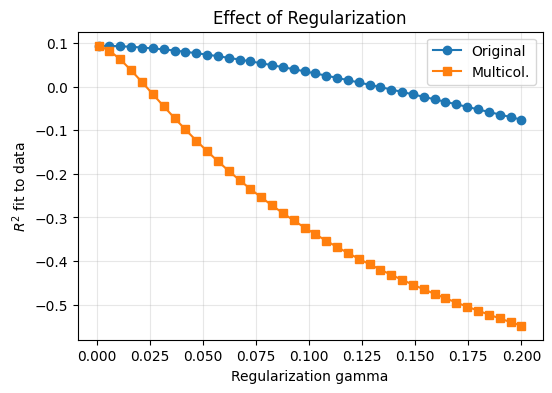

In [10]:
gammas = np.linspace(0.001, 0.2, 40)

r2_original = []
r2_multicol = []

X_original = desmat

for gamma in gammas:
    beta_o = regularized_beta(X_original, y, gamma)
    pred_o = X_original @ beta_o
    r2_o = 1 - np.sum((y - pred_o)**2) / np.sum((y - np.mean(y))**2)
    r2_original.append(float(r2_o))

    beta_m = regularized_beta(X_multi, y, gamma)
    pred_m = X_multi @ beta_m
    r2_m = 1 - np.sum((y - pred_m)**2) / np.sum((y - np.mean(y))**2)
    r2_multicol.append(float(r2_m))

plt.figure(figsize=(6, 4))
plt.plot(gammas, r2_original, "o-", label="Original")
plt.plot(gammas, r2_multicol, "s-", label="Multicol.")
plt.xlabel("Regularization gamma")
plt.ylabel("$R^2$ fit to data")
plt.title("Effect of Regularization")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Polynomial Regression

Polynomial regression adalah regresi biasa, tetapi design matrix dibuat dari nilai $x$ yang dipangkatkan. Jika order polynomial adalah $n$, maka design matrix berisi $n+1$ regressors, termasuk intercept.

### Rumus Polynomial Regression

$$
y = \beta_0x^0 + \beta_1x^1 + \cdots + \beta_nx^n
$$

Keterangan:

- $x^0=1$ = intercept
- $n$ = order polynomial
- $\beta_i$ = coefficient untuk regressor ke-$i$
- Polynomial regression tetap diselesaikan dengan least squares

Polynomial regression digunakan untuk curve fitting dan approximating nonlinear functions.

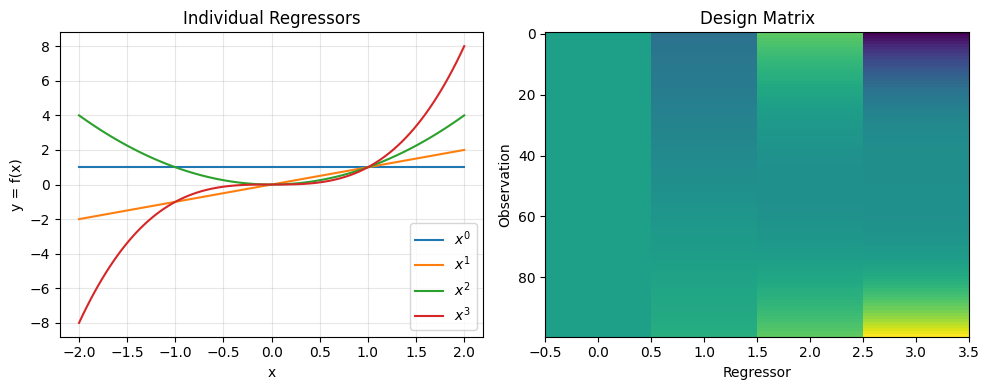

In [11]:
x = np.linspace(-2, 2, 100)

X_poly = np.zeros((len(x), 4))
for i in range(4):
    X_poly[:, i] = x**i

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for i in range(4):
    axes[0].plot(x, X_poly[:, i], label=f"$x^{i}$")
axes[0].set_title("Individual Regressors")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y = f(x)")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].imshow(X_poly, aspect="auto")
axes[1].set_title("Design Matrix")
axes[1].set_xlabel("Regressor")
axes[1].set_ylabel("Observation")

plt.tight_layout()
plt.show()

## Contoh Polynomial Regression: Population Doubling Time

Chapter menggunakan dataset kecil tentang waktu yang dibutuhkan populasi manusia untuk berlipat ganda. Model yang digunakan adalah third-order polynomial.

Contoh berikut menggunakan angka sederhana yang mengikuti pola pada chapter: doubling time menurun tajam lalu sedikit naik pada proyeksi masa depan.

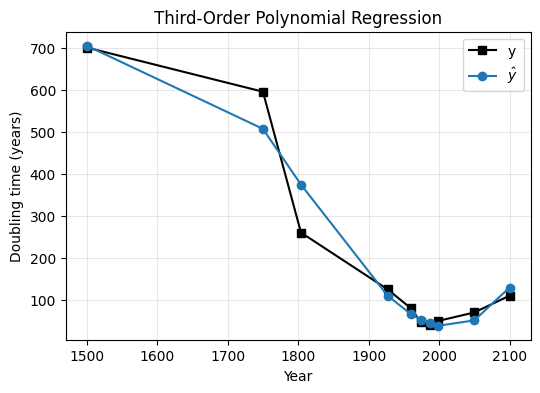

In [12]:
year = np.array([1500, 1750, 1804, 1927, 1960, 1974, 1987, 1999, 2050, 2100], dtype=float)
doubleTime = np.array([700, 595, 260, 125, 80, 47, 40, 50, 70, 110], dtype=float)

N = len(year)

# Untuk stabilitas numerik, gunakan year yang di-center
year_centered = year - np.mean(year)

X = np.zeros((N, 4))
for i in range(4):
    X[:, i] = year_centered**i

beta = np.linalg.lstsq(X, doubleTime, rcond=None)[0]
yHat = X @ beta

plt.figure(figsize=(6, 4))
plt.plot(year, doubleTime, "ks-", label="y")
plt.plot(year, yHat, "o-", label=r"$\hat{y}$")
plt.xlabel("Year")
plt.ylabel("Doubling time (years)")
plt.title("Third-Order Polynomial Regression")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## `np.polyfit()` dan `np.polyval()`

Polynomial regression umum digunakan, sehingga NumPy menyediakan fungsi khusus:

```python
np.polyfit(x, y, order)
np.polyval(beta, x)
```

Fungsi ini lebih ringkas dibanding membuat design matrix secara manual.

In [13]:
beta_np = np.polyfit(year_centered, doubleTime, 3)
yHat_np = np.polyval(beta_np, year_centered)

print("Beta from np.polyfit:")
print(np.round(beta_np, 4))

print("\nDifference between manual and np.polyfit prediction:")
print(np.linalg.norm(yHat - yHat_np))

Beta from np.polyfit:
[ 0.000000e+00  5.700000e-03 -1.841200e+00  1.472871e+02]

Difference between manual and np.polyfit prediction:
8.496451526707447e-09


## Underfitting dan Overfitting

Chapter exercises membahas fitting polynomial dari order 0 sampai 9. Order terlalu rendah dapat menyebabkan **underfitting**, yaitu model terlalu sederhana untuk menangkap pola data. Order terlalu tinggi dapat menyebabkan **overfitting**, yaitu model terlalu mengikuti noise dan sulit generalize ke data baru.

Strategi untuk mencari keseimbangan antara underfitting dan overfitting biasanya melibatkan cross-validation atau informasi statistik lain seperti Bayes information criterion.

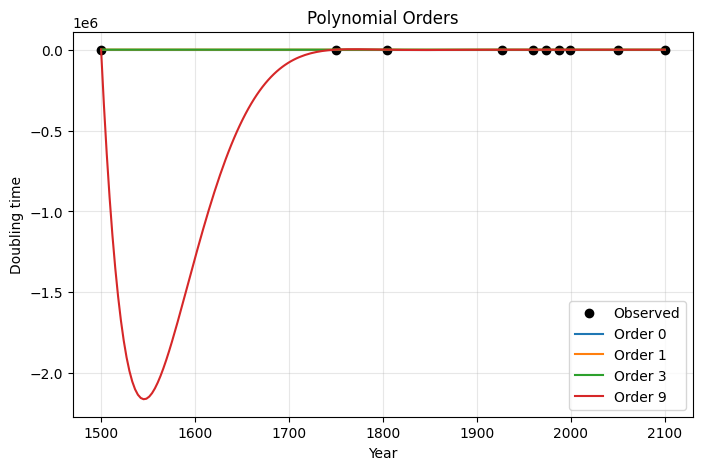

In [14]:
orders = [0, 1, 3, 9]

plt.figure(figsize=(8, 5))
plt.plot(year, doubleTime, "ko", label="Observed")

x_dense = np.linspace(year_centered.min(), year_centered.max(), 200)
year_dense = x_dense + np.mean(year)

for order in orders:
    coef = np.polyfit(year_centered, doubleTime, order)
    pred_dense = np.polyval(coef, x_dense)
    plt.plot(year_dense, pred_dense, label=f"Order {order}")

plt.xlabel("Year")
plt.ylabel("Doubling time")
plt.title("Polynomial Orders")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Grid Search to Find Model Parameters

Least squares cepat, akurat, dan deterministic, tetapi hanya berlaku untuk model linear. Grid search adalah metode pencarian parameter dengan mencoba banyak kombinasi nilai parameter, menghitung fit setiap kombinasi, lalu memilih yang error-nya paling kecil.

Langkah grid search:

1. Tentukan range parameter.
2. Tentukan resolusi grid.
3. Hitung prediksi untuk setiap kombinasi parameter.
4. Hitung error, misalnya sum of squared errors.
5. Pilih parameter dengan error terkecil.

Grid search berguna untuk model nonlinear atau hyperparameter tuning, tetapi bisa sangat lambat jika jumlah parameter besar.

## Rumus SSE pada Grid Search

Pada contoh model linear sederhana:

$$
\hat{y} = b_0 + b_1x
$$

fit dievaluasi menggunakan:

$$
SSE = \sum_{i=1}^{n}(y_i-\hat{y}_i)^2
$$

Keterangan:

- $b_0$ = intercept
- $b_1$ = slope
- $y_i$ = observed data
- $\hat{y}_i$ = predicted data
- Parameter terbaik adalah kombinasi dengan nilai $SSE$ paling kecil

In [15]:
# Data "happy student" sederhana seperti konsep chapter sebelumnya
numcourses = np.array([4, 12, 3, 14, 13, 12, 9, 11, 7, 13,
                       11, 9, 2, 5, 7, 10, 0, 9, 7, 14], dtype=float)

happiness = np.array([25, 54, 21, 80, 68, 84, 62, 57, 40, 60,
                      64, 45, 38, 51, 52, 58, 21, 75, 70, 70], dtype=float)

X_happy = np.column_stack((np.ones(len(numcourses)), numcourses))
beta_analytic = np.linalg.lstsq(X_happy, happiness, rcond=None)[0]

intercepts = np.linspace(0, 80, 80)
slopes = np.linspace(0, 6, 80)

sse_grid = np.zeros((len(intercepts), len(slopes)))

for i, intercept in enumerate(intercepts):
    for j, slope in enumerate(slopes):
        pred = intercept + slope*numcourses
        sse_grid[i, j] = np.sum((happiness - pred)**2)

min_idx = np.unravel_index(np.argmin(sse_grid), sse_grid.shape)
best_intercept = intercepts[min_idx[0]]
best_slope = slopes[min_idx[1]]

print("Analytic result:")
print(f"Intercept: {beta_analytic[0]:.2f}, slope: {beta_analytic[1]:.2f}")

print("\nEmpirical result:")
print(f"Intercept: {best_intercept:.2f}, slope: {best_slope:.2f}")

Analytic result:
Intercept: 23.51, slope: 3.63

Empirical result:
Intercept: 23.29, slope: 3.65


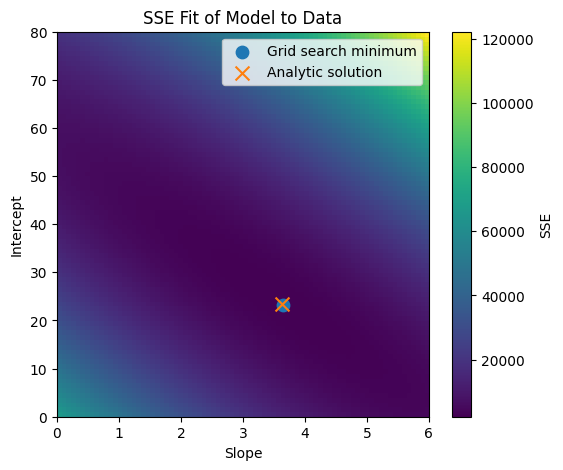

In [16]:
plt.figure(figsize=(6, 5))
plt.imshow(
    sse_grid,
    origin="lower",
    aspect="auto",
    extent=[slopes.min(), slopes.max(), intercepts.min(), intercepts.max()]
)
plt.colorbar(label="SSE")
plt.scatter(best_slope, best_intercept, marker="o", s=80, label="Grid search minimum")
plt.scatter(beta_analytic[1], beta_analytic[0], marker="x", s=100, label="Analytic solution")
plt.xlabel("Slope")
plt.ylabel("Intercept")
plt.title("SSE Fit of Model to Data")
plt.legend()
plt.show()

## Least Squares vs Grid Search

| Aspek | Least Squares | Grid Search |
|---|---|---|
| Jenis solusi | Analytic solution | Empirical search |
| Kecepatan | Cepat | Lebih lambat |
| Deterministik | Ya | Bergantung grid |
| Cocok untuk | Model linear | Model nonlinear atau hyperparameter search |
| Risiko | Membutuhkan design matrix yang sesuai | Sensitif terhadap range dan resolusi grid |

Chapter menyimpulkan bahwa grid search tidak perlu digunakan jika least squares adalah solusi yang valid. Grid search berguna saat model tidak dapat diselesaikan dengan linear least squares.

## Ringkasan Konsep Penting

| Konsep | Ringkasan |
|---|---|
| Least squares application | Digunakan untuk fitting model pada data nyata. |
| Visual inspection | Penting sebelum memilih dan menafsirkan model statistik. |
| Design matrix | Matrix berisi regressors dan intercept. |
| $R^2$ | Ukuran proporsi variance yang dijelaskan model. |
| Regression table | Ringkasan statistik dari model regresi. |
| Multicollinearity | Linear dependence pada design matrix. |
| Reduced-rank matrix | Matrix dengan rank lebih kecil dari jumlah columns. |
| Minimum norm solution | Solusi untuk reduced-rank GLM menggunakan pseudoinverse. |
| Regularization | Shifting matrix untuk meningkatkan stabilitas numerik. |
| Frobenius norm scaling | Regularization diskalakan dengan $\|X\|_F^2$. |
| Polynomial regression | Regresi dengan regressors berupa pangkat-pangkat $x$. |
| Underfitting | Model terlalu sederhana. |
| Overfitting | Model terlalu mengikuti data/noise. |
| Grid search | Pencarian parameter dengan mencoba kombinasi pada grid. |

## Kesimpulan Chapter

Chapter ini menunjukkan bahwa least squares tidak hanya konsep linear algebra, tetapi juga alat penting untuk modeling data nyata. Pada contoh bike rental, model linear sederhana dapat dihitung dengan mudah, tetapi hasilnya tidak terlalu baik. Ini menegaskan pentingnya inspeksi visual data dan pemilihan model yang sesuai.

Regression table melalui `statsmodels` memberi informasi statistik yang lebih lengkap, tetapi interpretasinya tetap membutuhkan pemahaman konsep dasar, terutama hubungan antara design matrix, coefficients, dan model fit.

Multicollinearity dijelaskan sebagai linear dependence pada design matrix. Jika design matrix reduced-rank, solusi least squares menggunakan inverse biasa dapat menjadi tidak stabil. Regularization menjadi salah satu cara untuk meningkatkan stabilitas dengan menambahkan shifting pada matrix.

Polynomial regression memperluas regresi linear dengan membentuk design matrix dari pangkat-pangkat $x$, sehingga dapat digunakan untuk curve fitting. Namun, pemilihan order polynomial harus hati-hati agar tidak underfit atau overfit.

Grid search diperkenalkan sebagai alternatif pencarian parameter untuk model yang tidak bisa diselesaikan dengan least squares. Walaupun lebih lambat dan bergantung pada grid, metode ini berguna untuk nonlinear models dan hyperparameter tuning. Secara keseluruhan, chapter ini memperlihatkan bahwa pemahaman linear algebra membantu memilih model, menafsirkan hasil, dan mengantisipasi masalah numerik dalam data science.